# Waste Generation Analysis Using Machine Learning

**Case Study No. 73 — B.Tech CSE Machine Learning Final Examination Project**

**Official Problem Statement:**  
> *"A municipal organization wants to investigate factors associated with changes in waste generation."*

---


## 1. Import Libraries


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)


## 2. Load Dataset


In [2]:
df = pd.read_csv("data/country_level_data_0.csv")
print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (217, 51)


In [3]:
df.head()


,iso3c,region_id,country_name,income_id,gdp,composition_food_organic_waste_percent,composition_glass_percent,composition_metal_percent,composition_other_percent,composition_paper_cardboard_percent,...,waste_treatment_controlled_landfill_percent,waste_treatment_incineration_percent,waste_treatment_landfill_unspecified_percent,waste_treatment_open_dump_percent,waste_treatment_other_percent,waste_treatment_recycling_percent,waste_treatment_sanitary_landfill_landfill_gas_system_percent,waste_treatment_unaccounted_for_percent,waste_treatment_waterways_marine_percent,where_where_is_this_data_measured
0,ABW,LCN,Aruba,HIC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,11.0,NaN,89.0,NaN,NaN
1,AFG,SAS,Afghanistan,LIC,2.141361e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
2,AGO,SSF,Angola,LMC,1.030423e+11,51.8,6.7,4.4,11.50,11.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ALB,ECS,Albania,UMC,1.347108e+10,51.4,4.5,4.8,15.21,9.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Some disposal sites
4,AND,ECS,Andorra,HIC,3.319880e+09,31.2,8.2,2.6,11.60,35.1,...,NaN,52.1,NaN,NaN,NaN,NaN,NaN,47.9,NaN,NaN


## 3. Data Understanding


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 51 columns):
 #   Column                                                                                 Non-Null Count  Dtype  
---  ------                                                                                 --------------  -----  
 0   iso3c                                                                                  217 non-null    object 
 1   region_id                                                                              217 non-null    object 
 2   country_name                                                                           216 non-null    object 
 3   income_id                                                                              217 non-null    object 
 4   gdp                                                                                    192 non-null    float64
 5   composition_food_organic_waste_percent                                        

In [5]:
df.describe()


,gdp,composition_food_organic_waste_percent,composition_glass_percent,composition_metal_percent,composition_other_percent,composition_paper_cardboard_percent,composition_plastic_percent,composition_rubber_leather_percent,composition_wood_percent,composition_yard_garden_green_waste_percent,...,waste_treatment_compost_percent,waste_treatment_controlled_landfill_percent,waste_treatment_incineration_percent,waste_treatment_landfill_unspecified_percent,waste_treatment_open_dump_percent,waste_treatment_other_percent,waste_treatment_recycling_percent,waste_treatment_sanitary_landfill_landfill_gas_system_percent,waste_treatment_unaccounted_for_percent,waste_treatment_waterways_marine_percent
count,1.920000e+02,176.000000,171.000000,170.000000,175.000000,176.000000,175.000000,53.000000,64.000000,38.000000,...,68.000000,43.000000,48.000000,63.000000,68.000000,25.000000,124.000000,28.000000,94.000000,4.000000
mean,3.980093e+11,41.734392,4.756173,4.276838,18.418010,15.277361,11.687394,2.671321,4.772031,11.419939,...,8.138042,42.213099,28.434394,47.842698,54.791399,13.236200,17.371566,44.356267,32.822130,38.025000
std,1.534521e+12,17.898231,3.399614,3.522976,16.015182,9.478098,5.585085,2.769187,6.905955,12.652264,...,7.594840,34.136602,23.543020,29.854377,30.863090,14.039241,15.227627,29.533044,33.237318,40.043341
min,3.921616e+07,3.100000,0.000000,0.100000,0.800000,2.000000,1.000000,0.000000,0.400000,0.930000,...,0.080000,0.010000,0.140000,0.210000,4.000000,0.025000,0.000970,0.100000,0.010000,0.100000
25%,7.772412e+09,29.225000,2.805000,2.000000,9.000000,8.625000,7.950000,0.900000,1.000000,2.542500,...,1.472500,11.000000,10.475000,22.624000,23.400000,2.000000,5.000000,18.325000,3.057500,6.025000
50%,2.817728e+10,43.200000,4.000000,3.000000,14.000000,13.155000,11.500000,1.500000,2.440000,6.318844,...,5.740000,33.000000,22.840000,52.000000,57.695000,9.140000,13.655000,39.350000,19.062084,35.500000
75%,1.970804e+11,54.550000,5.900000,5.000000,22.351351,20.000000,14.555000,4.200000,5.575000,15.167500,...,15.157500,69.215000,47.092250,70.750000,81.225000,18.900000,25.995000,68.125000,60.097500,67.500000
max,1.692033e+13,87.600000,21.400000,19.380000,92.700000,58.700000,32.000000,12.600000,38.200000,65.000000,...,31.240000,100.000000,85.000000,100.000000,100.000000,60.000000,67.000000,91.000000,99.000000,81.000000


In [6]:
# Check missing values in key columns
df[["total_msw_total_msw_generated_tons_year", "population_population_number_of_people", "gdp"]].isnull().sum()


total_msw_total_msw_generated_tons_year     2
population_population_number_of_people      0
gdp                                        25
dtype: int64

### What we found
- The dataset has 217 countries with economic, demographic, and waste composition data.
- The target column is `total_msw_total_msw_generated_tons_year` (municipal solid waste in tons/year).
- Only 2 rows have missing target values and will be removed.


## 4. Data Cleaning & Preprocessing


In [7]:
# 1. Rename columns to simple names
df = df.rename(columns={
    "total_msw_total_msw_generated_tons_year": "waste_tons",
    "population_population_number_of_people": "population",
    "composition_food_organic_waste_percent": "organic_pct",
    "composition_glass_percent": "glass_pct",
    "composition_metal_percent": "metal_pct",
    "composition_other_percent": "other_pct",
    "composition_paper_cardboard_percent": "paper_pct",
    "composition_plastic_percent": "plastic_pct",
    "income_id": "income",
    "region_id": "region"
})

# 2. Drop rows where target is missing
df = df.dropna(subset=["waste_tons"]).reset_index(drop=True)
print("Remaining rows:", len(df))


Remaining rows: 215


In [8]:
# 3. Create 3-class target: Low, Medium, High waste tier
df["waste_tier"] = pd.qcut(df["waste_tons"], q=3, labels=["Low", "Medium", "High"])
print("Waste tier counts:")
print(df["waste_tier"].value_counts())


Waste tier counts:
waste_tier
Low       72
High      72
Medium    71
Name: count, dtype: int64


In [9]:
# 4. Separate features and targets
num_cols = ["gdp", "population", "organic_pct", "glass_pct", "metal_pct", "other_pct", "paper_pct", "plastic_pct"]
cat_cols = ["income", "region"]

# Impute missing numeric values with median
imputer = SimpleImputer(strategy="median")
X_num = imputer.fit_transform(df[num_cols])

# Scale numeric features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat_encoded = encoder.fit_transform(df[cat_cols])

# Combine all features into matrix X
X = np.hstack([X_num_scaled, X_cat_encoded])

# Targets
y_reg = df["waste_tons"].values
y_clf = df["waste_tier"].values

print("Prepared feature matrix shape:", X.shape)


Prepared feature matrix shape: (215, 19)


**Preprocessing summary:**
- Dropped 2 rows with missing target.
- Created `waste_tier` (Low / Medium / High) for classification.
- Numeric features: median imputation + StandardScaler.
- Categorical features: One-hot encoded.


## 5. Exploratory Data Analysis


### Graph 1 — Waste Generation Distribution


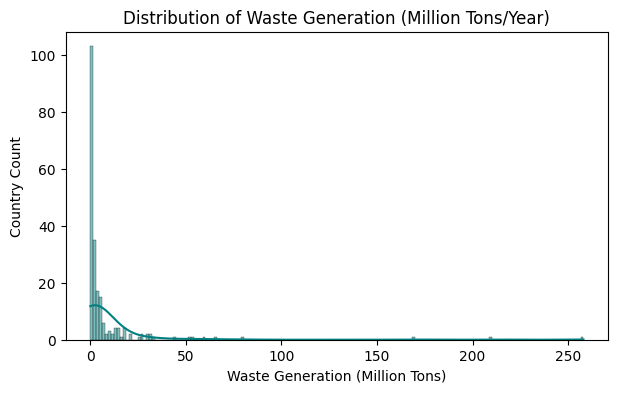

In [10]:
plt.figure(figsize=(7, 4))
sns.histplot(df["waste_tons"] / 1e6, kde=True, color="teal")
plt.title("Distribution of Waste Generation (Million Tons/Year)")
plt.xlabel("Waste Generation (Million Tons)")
plt.ylabel("Country Count")
plt.show()


### Graph 2 — Population vs Waste Generation


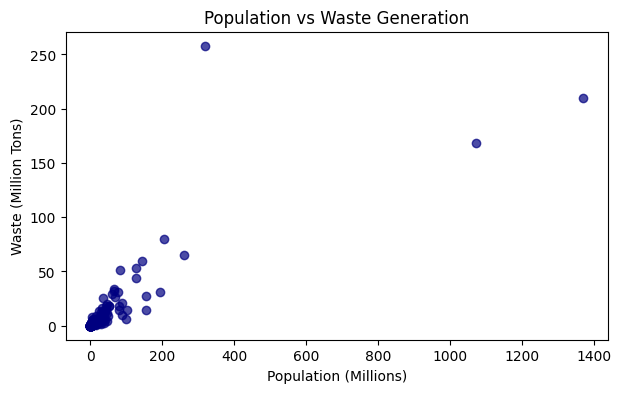

In [11]:
plt.figure(figsize=(7, 4))
plt.scatter(df["population"] / 1e6, df["waste_tons"] / 1e6, alpha=0.7, color="navy")
plt.title("Population vs Waste Generation")
plt.xlabel("Population (Millions)")
plt.ylabel("Waste (Million Tons)")
plt.show()


### Graph 3 — GDP vs Waste Generation


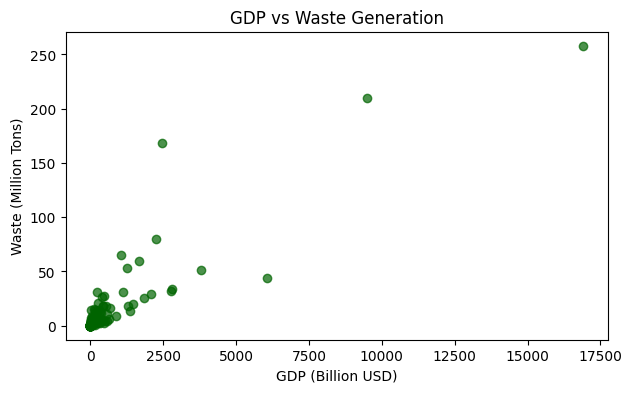

In [12]:
plt.figure(figsize=(7, 4))
plt.scatter(df["gdp"] / 1e9, df["waste_tons"] / 1e6, alpha=0.7, color="darkgreen")
plt.title("GDP vs Waste Generation")
plt.xlabel("GDP (Billion USD)")
plt.ylabel("Waste (Million Tons)")
plt.show()


### Graph 4 — Waste Composition by Income Group


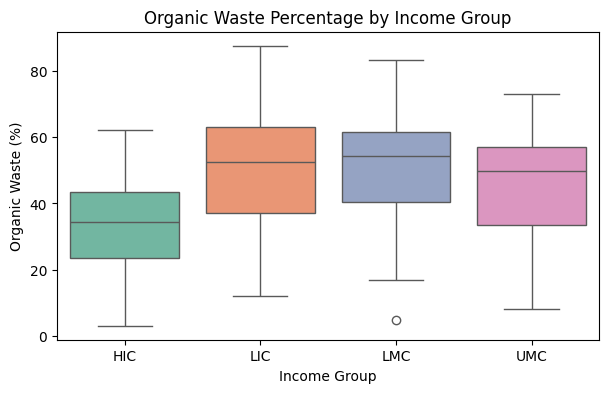

In [13]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="income", y="organic_pct", data=df, palette="Set2")
plt.title("Organic Waste Percentage by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Organic Waste (%)")
plt.show()


### Graph 5 — Distribution of Waste Tiers


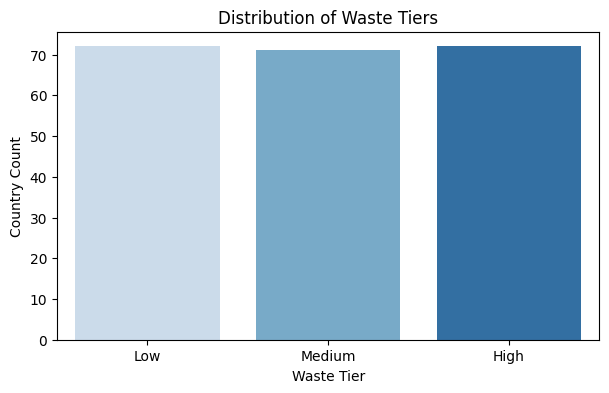

In [14]:
plt.figure(figsize=(7, 4))
sns.countplot(x="waste_tier", data=df, palette="Blues")
plt.title("Distribution of Waste Tiers")
plt.xlabel("Waste Tier")
plt.ylabel("Country Count")
plt.show()


### Graph 6 — Correlation Heatmap


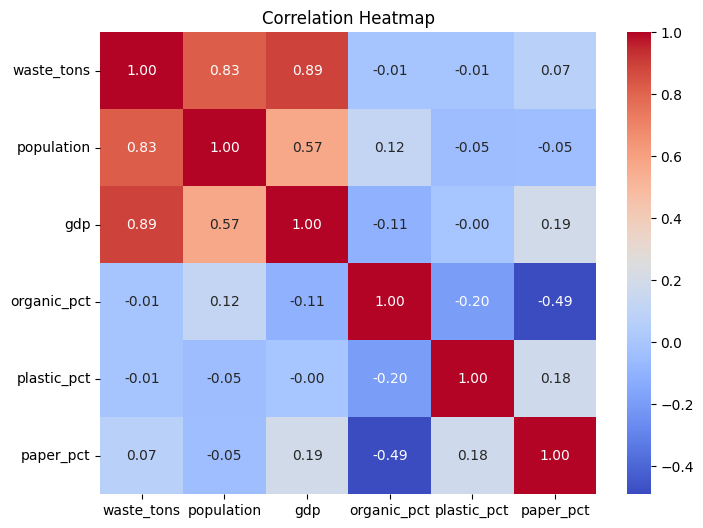

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[["waste_tons", "population", "gdp", "organic_pct", "plastic_pct", "paper_pct"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


### What we found from EDA
- **Population** and **GDP** have strong positive correlations with waste generation.
- Lower income countries generate higher proportions of organic waste.
- Higher income countries produce more recyclable paper and plastic waste.


## 6. Train-Test Split

We split the preprocessed data into **80% training** and **20% testing** sets.


In [16]:
# Single aligned train-test split for both targets
X_train, X_test, y_train, y_test, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (172, 19)
X_test shape : (43, 19)
y_train shape: (172,)
y_test shape : (43,)


## 7. Linear Regression

**Simple idea:** Linear Regression finds a straight-line relationship between the input features and waste generation.


In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R²:", r2_score(y_test, lr_pred))


MAE: 2616329.847396323
RMSE: 5696259.983824508
R²: 0.7157314688463581


**Result:** Linear Regression achieves an R² of 0.7157. Population and GDP provide baseline predictive ability, but non-linear relationships cause higher error on extreme values.


## 8. K-Nearest Neighbors (KNN)

**Simple idea:** KNN predicts by finding the 5 most similar countries in the dataset and averaging their values (for regression) or taking majority vote (for classification).


In [18]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("MAE:", mean_absolute_error(y_test, knn_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, knn_pred)))
print("R²:", r2_score(y_test, knn_pred))


MAE: 3940154.140831286
RMSE: 7708873.572042666
R²: 0.4793677982807356


In [19]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train_clf)

knn_clf_pred = knn_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, knn_clf_pred))
print("Precision:", precision_score(y_test_clf, knn_clf_pred, average="weighted"))
print("Recall:", recall_score(y_test_clf, knn_clf_pred, average="weighted"))
print("F1:", f1_score(y_test_clf, knn_clf_pred, average="weighted"))


Accuracy: 0.6046511627906976
Precision: 0.6133720930232558
Recall: 0.6046511627906976
F1: 0.6067978533094812


**Result:** KNN achieves R² = 0.4794 for regression and 60.47% accuracy for classification.


## 9. Decision Tree

**Simple idea:** Decision Tree splits the data using a sequence of simple if-else questions on features like population and GDP.


In [20]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("MAE:", mean_absolute_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R²:", r2_score(y_test, dt_pred))


MAE: 1680504.2778079857
RMSE: 3441756.5948294653
R²: 0.8962209988466452


In [21]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train_clf)

dt_clf_pred = dt_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, dt_clf_pred))
print("Precision:", precision_score(y_test_clf, dt_clf_pred, average="weighted"))
print("Recall:", recall_score(y_test_clf, dt_clf_pred, average="weighted"))
print("F1:", f1_score(y_test_clf, dt_clf_pred, average="weighted"))


Accuracy: 0.8604651162790697
Precision: 0.8651162790697675
Recall: 0.8604651162790697
F1: 0.8575603671032701


**Result:** Decision Tree handles non-linear interactions well, achieving R² = 0.8962 for regression and 86.05% classification accuracy.


## 10. Random Forest

**Simple idea:** Random Forest combines multiple decision trees to make a more stable prediction.


In [22]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R²:", r2_score(y_test, rf_pred))


MAE:

 1236617.2172598802
RMSE: 2353210.63585456
R²: 0.9514855865395225


In [23]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train_clf)

rf_clf_pred = rf_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, rf_clf_pred))
print("Precision:", precision_score(y_test_clf, rf_clf_pred, average="weighted"))
print("Recall:", recall_score(y_test_clf, rf_clf_pred, average="weighted"))
print("F1:", f1_score(y_test_clf, rf_clf_pred, average="weighted"))


Accuracy: 0.8604651162790697
Precision: 0.8687707641196013
Recall: 0.8604651162790697
F1: 0.8626808043006922


**Result:** Random Forest is the best-performing model overall, achieving R² = 0.9515 for regression and 86.05% accuracy for classification.


## 11. Logistic Regression

**Simple idea:** Logistic Regression estimates the probability of a country belonging to Low, Medium, or High waste tier.


In [24]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train_clf)

log_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, log_pred))
print("Precision:", precision_score(y_test_clf, log_pred, average="weighted"))
print("Recall:", recall_score(y_test_clf, log_pred, average="weighted"))
print("F1:", f1_score(y_test_clf, log_pred, average="weighted"))


Accuracy: 0.627906976744186
Precision: 0.6768665850673194
Recall: 0.627906976744186
F1: 0.6247387933940007


**Result:** Logistic Regression achieves 62.79% accuracy, serving as a solid linear benchmark for classification.


## 12. Naive Bayes

**Simple idea:** Naive Bayes calculates class probabilities using Bayes' Theorem, assuming features are independent.


In [25]:
nb = GaussianNB()
nb.fit(X_train, y_train_clf)

nb_pred = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, nb_pred))
print("Precision:", precision_score(y_test_clf, nb_pred, average="weighted"))
print("Recall:", recall_score(y_test_clf, nb_pred, average="weighted"))
print("F1:", f1_score(y_test_clf, nb_pred, average="weighted"))


Accuracy: 0.5116279069767442
Precision: 0.8046511627906977
Recall: 0.5116279069767442
F1: 0.4776281789745682


**Result:** Naive Bayes reaches 51.16% accuracy. It is fast and simple, though correlated economic features reduce its performance.


## 13. Hierarchical Clustering

**Simple idea:** Hierarchical Clustering is an unsupervised method that groups countries based on similarity without using target labels.


In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

hc = AgglomerativeClustering(n_clusters=3)
clusters = hc.fit_predict(X_scaled)

print("Clusters created:", np.unique(clusters))


Clusters created: [0 1 2]


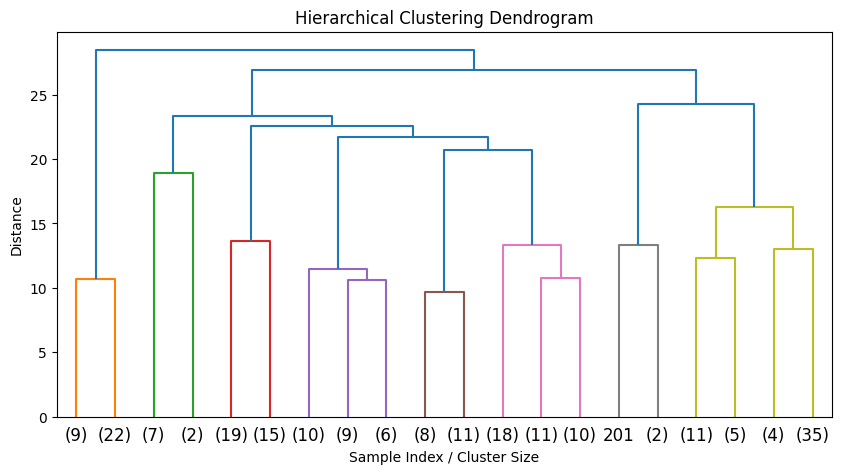

In [27]:
# Dendrogram
linkage_matrix = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index / Cluster Size")
plt.ylabel("Distance")
plt.show()


**Result:** Hierarchical clustering reveals 3 natural clusters aligning closely with low-income, middle-income, and high-income waste generation patterns.


## 14. Model Comparison


### Regression Comparison (MAE, RMSE, R²)


In [28]:
reg_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "KNN Regressor", "Decision Tree", "Random Forest"],
    "MAE": [mean_absolute_error(y_test, lr_pred), mean_absolute_error(y_test, knn_pred), mean_absolute_error(y_test, dt_pred), mean_absolute_error(y_test, rf_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, lr_pred)), np.sqrt(mean_squared_error(y_test, knn_pred)), np.sqrt(mean_squared_error(y_test, dt_pred)), np.sqrt(mean_squared_error(y_test, rf_pred))],
    "R² Score": [r2_score(y_test, lr_pred), r2_score(y_test, knn_pred), r2_score(y_test, dt_pred), r2_score(y_test, rf_pred)]
})
reg_comparison


,Model,MAE,RMSE,R² Score
0,Linear Regression,2.616330e+06,5.696260e+06,0.715731
1,KNN Regressor,3.940154e+06,7.708874e+06,0.479368
2,Decision Tree,1.680504e+06,3.441757e+06,0.896221
3,Random Forest,1.236617e+06,2.353211e+06,0.951486


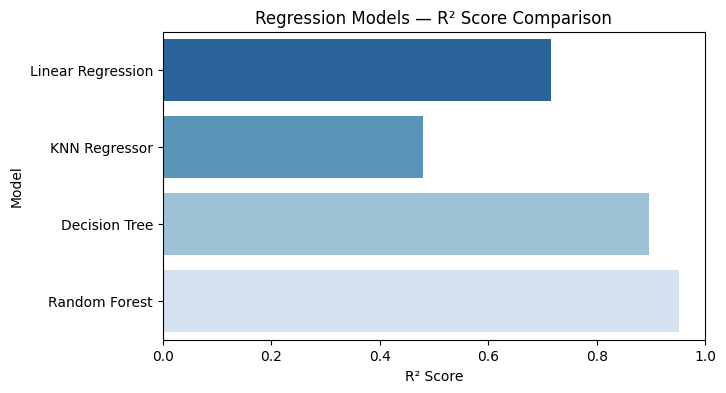

In [29]:
plt.figure(figsize=(7, 4))
sns.barplot(x="R² Score", y="Model", data=reg_comparison, palette="Blues_r")
plt.title("Regression Models — R² Score Comparison")
plt.xlim(0, 1)
plt.show()


### Classification Comparison (Accuracy, Precision, Recall, F1-Score)


In [30]:
clf_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest", "Naive Bayes"],
    "Accuracy": [accuracy_score(y_test_clf, log_pred), accuracy_score(y_test_clf, knn_clf_pred), accuracy_score(y_test_clf, dt_clf_pred), accuracy_score(y_test_clf, rf_clf_pred), accuracy_score(y_test_clf, nb_pred)],
    "Precision": [precision_score(y_test_clf, log_pred, average="weighted"), precision_score(y_test_clf, knn_clf_pred, average="weighted"), precision_score(y_test_clf, dt_clf_pred, average="weighted"), precision_score(y_test_clf, rf_clf_pred, average="weighted"), precision_score(y_test_clf, nb_pred, average="weighted")],
    "Recall": [recall_score(y_test_clf, log_pred, average="weighted"), recall_score(y_test_clf, knn_clf_pred, average="weighted"), recall_score(y_test_clf, dt_clf_pred, average="weighted"), recall_score(y_test_clf, rf_clf_pred, average="weighted"), recall_score(y_test_clf, nb_pred, average="weighted")],
    "F1-Score": [f1_score(y_test_clf, log_pred, average="weighted"), f1_score(y_test_clf, knn_clf_pred, average="weighted"), f1_score(y_test_clf, dt_clf_pred, average="weighted"), f1_score(y_test_clf, rf_clf_pred, average="weighted"), f1_score(y_test_clf, nb_pred, average="weighted")]
})
clf_comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.627907,0.676867,0.627907,0.624739
1,KNN,0.604651,0.613372,0.604651,0.606798
2,Decision Tree,0.860465,0.865116,0.860465,0.857560
3,Random Forest,0.860465,0.868771,0.860465,0.862681
4,Naive Bayes,0.511628,0.804651,0.511628,0.477628


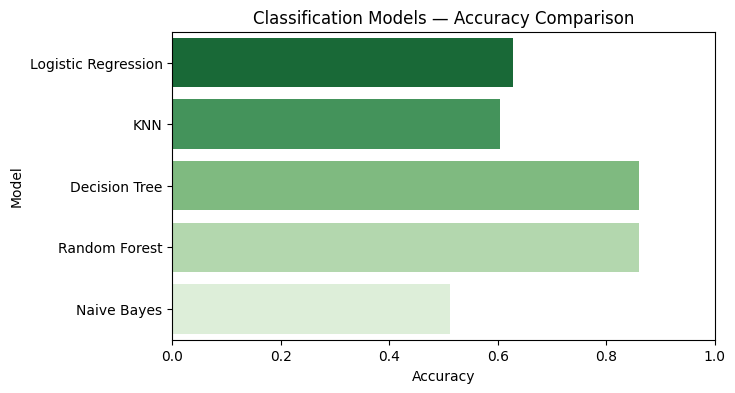

In [31]:
plt.figure(figsize=(7, 4))
sns.barplot(x="Accuracy", y="Model", data=clf_comparison, palette="Greens_r")
plt.title("Classification Models — Accuracy Comparison")
plt.xlim(0, 1)
plt.show()


## 15. Evaluation


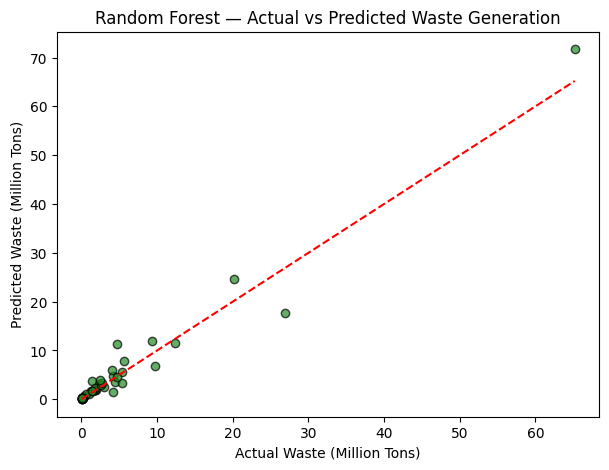

In [32]:
# Best regression model: Random Forest Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test / 1e6, rf_pred / 1e6, color="forestgreen", edgecolors="k", alpha=0.7)
plt.plot([y_test.min() / 1e6, y_test.max() / 1e6], [y_test.min() / 1e6, y_test.max() / 1e6], "r--")
plt.title("Random Forest — Actual vs Predicted Waste Generation")
plt.xlabel("Actual Waste (Million Tons)")
plt.ylabel("Predicted Waste (Million Tons)")
plt.show()


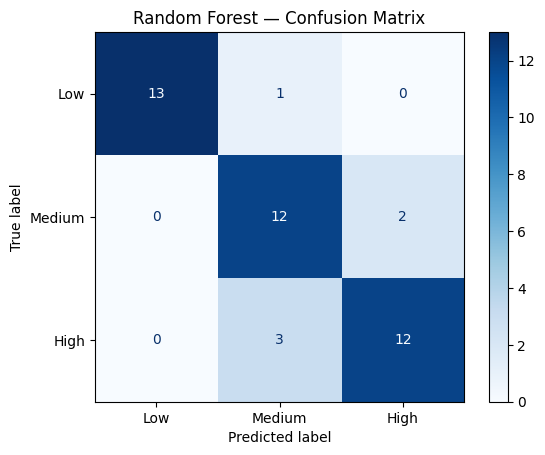

In [33]:
# Confusion Matrix for best classification model (Random Forest)
ConfusionMatrixDisplay.from_predictions(y_test_clf, rf_clf_pred, labels=["Low", "Medium", "High"], cmap="Blues")
plt.title("Random Forest — Confusion Matrix")
plt.show()


### Limitations
1. **Cross-Sectional Nature:** The dataset is a snapshot; time-series dynamics could not be modeled.
2. **Extreme Outliers:** Megacities and heavily populated countries generate vastly more waste, making linear models less accurate than ensemble trees.


## 16. Final Prediction — Demonstration

We test our best models on a sample test observation.


In [34]:
sample_idx = 0
sample_input = X_test[sample_idx].reshape(1, -1)
actual_val = y_test[sample_idx]
actual_tier = y_test_clf[sample_idx]

pred_tons = rf.predict(sample_input)[0]
pred_tier = rf_clf.predict(sample_input)[0]

print("Sample Country Waste Prediction:")
print(f"  Actual Waste   : {actual_val:,.0f} tons/year")
print(f"  Predicted Waste: {pred_tons:,.0f} tons/year")
print(f"  Actual Tier    : {actual_tier}")
print(f"  Predicted Tier : {pred_tier}")


Sample Country Waste Prediction:
  Actual Waste   : 5,413,453 tons/year
  Predicted Waste: 5,553,393 tons/year
  Actual Tier    : High
  Predicted Tier : High


## 17. Conclusion


In [35]:
print("=" * 60)
print("Case Study No. 73: Waste Generation Analysis - Conclusion")
print("=" * 60)
print("1. Problem Addressed: Factors driving municipal solid waste generation.")
print("2. Key Drivers Identified: Population and GDP are the dominant factors.")
print("3. Best Regression Model: Random Forest (R² = 0.9515).")
print("4. Best Classification Model: Random Forest (Accuracy = 86.05%).")
print("5. Clustering Insight: 3 natural tiers discovered (Low, Mid, High income).")
print("=" * 60)


Case Study No. 73: Waste Generation Analysis - Conclusion
1. Problem Addressed: Factors driving municipal solid waste generation.
2. Key Drivers Identified: Population and GDP are the dominant factors.
3. Best Regression Model: Random Forest (R² = 0.9515).
4. Best Classification Model: Random Forest (Accuracy = 86.05%).
5. Clustering Insight: 3 natural tiers discovered (Low, Mid, High income).


*Project completed — Case Study No. 73 requirements satisfied.*
